# JMD Parameter Tuning
Testing different JMD parameter combinations on sample PCG signals to find optimal settings for heart sound decomposition.

In [1]:
# loading libraries and JMD module

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path
from time import time
import sys

PROJECT_ROOT = Path(r"D:\sop")
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
SAMPLE_RATE = 1000

sys.path.insert(0, str(PROJECT_ROOT / 'decomposition'))
from jmd import JMD

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Ready.")

Ready.


## Loading test signals
Picking one non-augmented sample from absent and present classes. Using the first 5 seconds (5,000 samples) of each for consistent comparison across parameter sweeps. Full-length processing happens in the batch decomposition step.

In [2]:
# loading metadata and selecting test samples

df = pd.read_csv(PROJECT_ROOT / 'data' / 'file_metadata.csv')

absent_orig = df[(df['class'] == 'absent') & (~df['is_augmented'])]
present_orig = df[(df['class'] == 'present') & (~df['is_augmented'])]

absent_row = absent_orig.sample(1, random_state=42).iloc[0]
present_row = present_orig.sample(1, random_state=42).iloc[0]

CLIP_SECONDS = 5
CLIP_SAMPLES = CLIP_SECONDS * SAMPLE_RATE

sig_absent = np.load(absent_row['npy_path']).astype(np.float64)[:CLIP_SAMPLES]
sig_present = np.load(present_row['npy_path']).astype(np.float64)[:CLIP_SAMPLES]

print(f"Dataset: {len(df)} files total")
print(f"  Absent originals:  {len(absent_orig)}")
print(f"  Present originals: {len(present_orig)}")
print(f"")
print(f"Selected absent:  {absent_row['file']} (using first {CLIP_SECONDS}s)")
print(f"Selected present: {present_row['file']} (using first {CLIP_SECONDS}s)")
print(f"")
print(f"Absent  RMS: {np.sqrt(np.mean(sig_absent**2)):.4f}")
print(f"Present RMS: {np.sqrt(np.mean(sig_present**2)):.4f}")

Dataset: 7173 files total
  Absent originals:  2391
  Present originals: 616

Selected absent:  a361_PV.wav (using first 5s)
Selected present: p120_MV.wav (using first 5s)

Absent  RMS: 0.0767
Present RMS: 0.1829


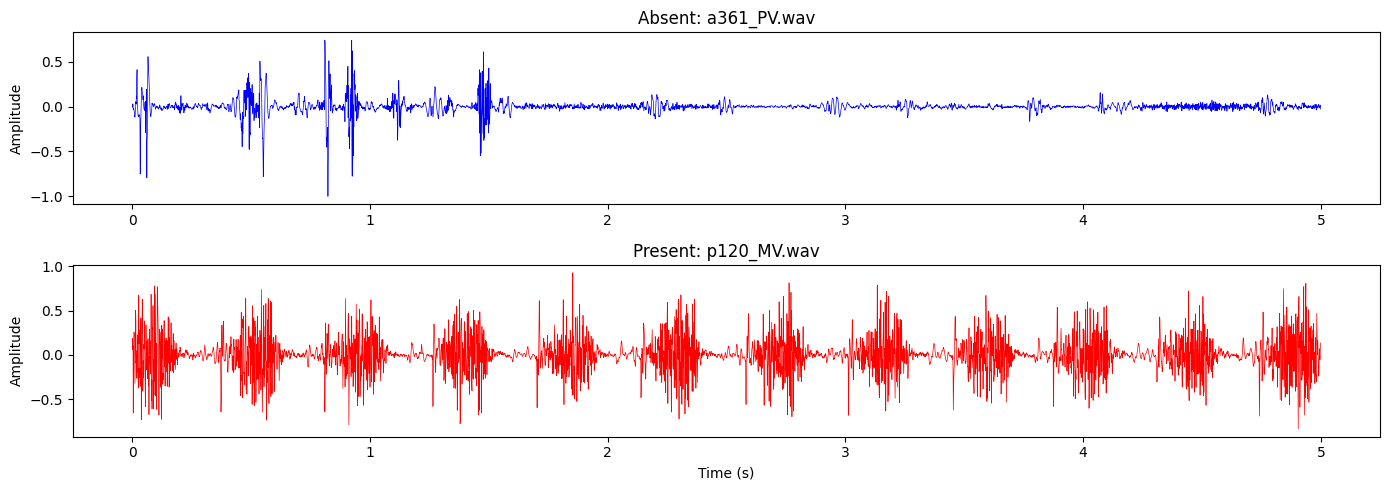

In [3]:
# plotting selected test signals

t = np.arange(CLIP_SAMPLES) / SAMPLE_RATE

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

axes[0].plot(t, sig_absent, 'b', linewidth=0.5)
axes[0].set_title(f'Absent: {absent_row["file"]}')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t, sig_present, 'r', linewidth=0.5)
axes[1].set_title(f'Present: {present_row["file"]}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## Testing K values (number of modes)
Testing K = 3, 4, 5, 6 with fixed alpha=5000, tau=5, beta=0.03, b_bar=0.45.

In [4]:
# running K sweep on both samples

K_values = [3, 4, 5, 6]
base_params = {'alpha': 5000, 'tau': 5, 'beta': 0.03, 'b_bar': 0.45, 'tol': 1e-6}

results_absent = {}
results_present = {}

print("K sweep on absent sample:")
for K in K_values:
    print(f"  K={K}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_absent, K=K, **base_params)
    elapsed = time() - t0
    results_absent[K] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s, freqs: {[f'{w*SAMPLE_RATE:.0f}' for w in omega]} Hz")

print("\nK sweep on present sample:")
for K in K_values:
    print(f"  K={K}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_present, K=K, **base_params)
    elapsed = time() - t0
    results_present[K] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s, freqs: {[f'{w*SAMPLE_RATE:.0f}' for w in omega]} Hz")

K sweep on absent sample:
  K=3... 40.1s, freqs: ['34', '48', '175'] Hz
  K=4... 42.6s, freqs: ['34', '49', '82', '176'] Hz
  K=5... 42.5s, freqs: ['32', '50', '101', '152', '178'] Hz
  K=6... 55.2s, freqs: ['33', '46', '72', '105', '175', '269'] Hz

K sweep on present sample:
  K=3... 35.9s, freqs: ['86', '152', '214'] Hz
  K=4... 34.9s, freqs: ['73', '117', '158', '235'] Hz
  K=5... 48.4s, freqs: ['75', '118', '156', '217', '267'] Hz
  K=6... 48.1s, freqs: ['77', '117', '150', '191', '251', '332'] Hz


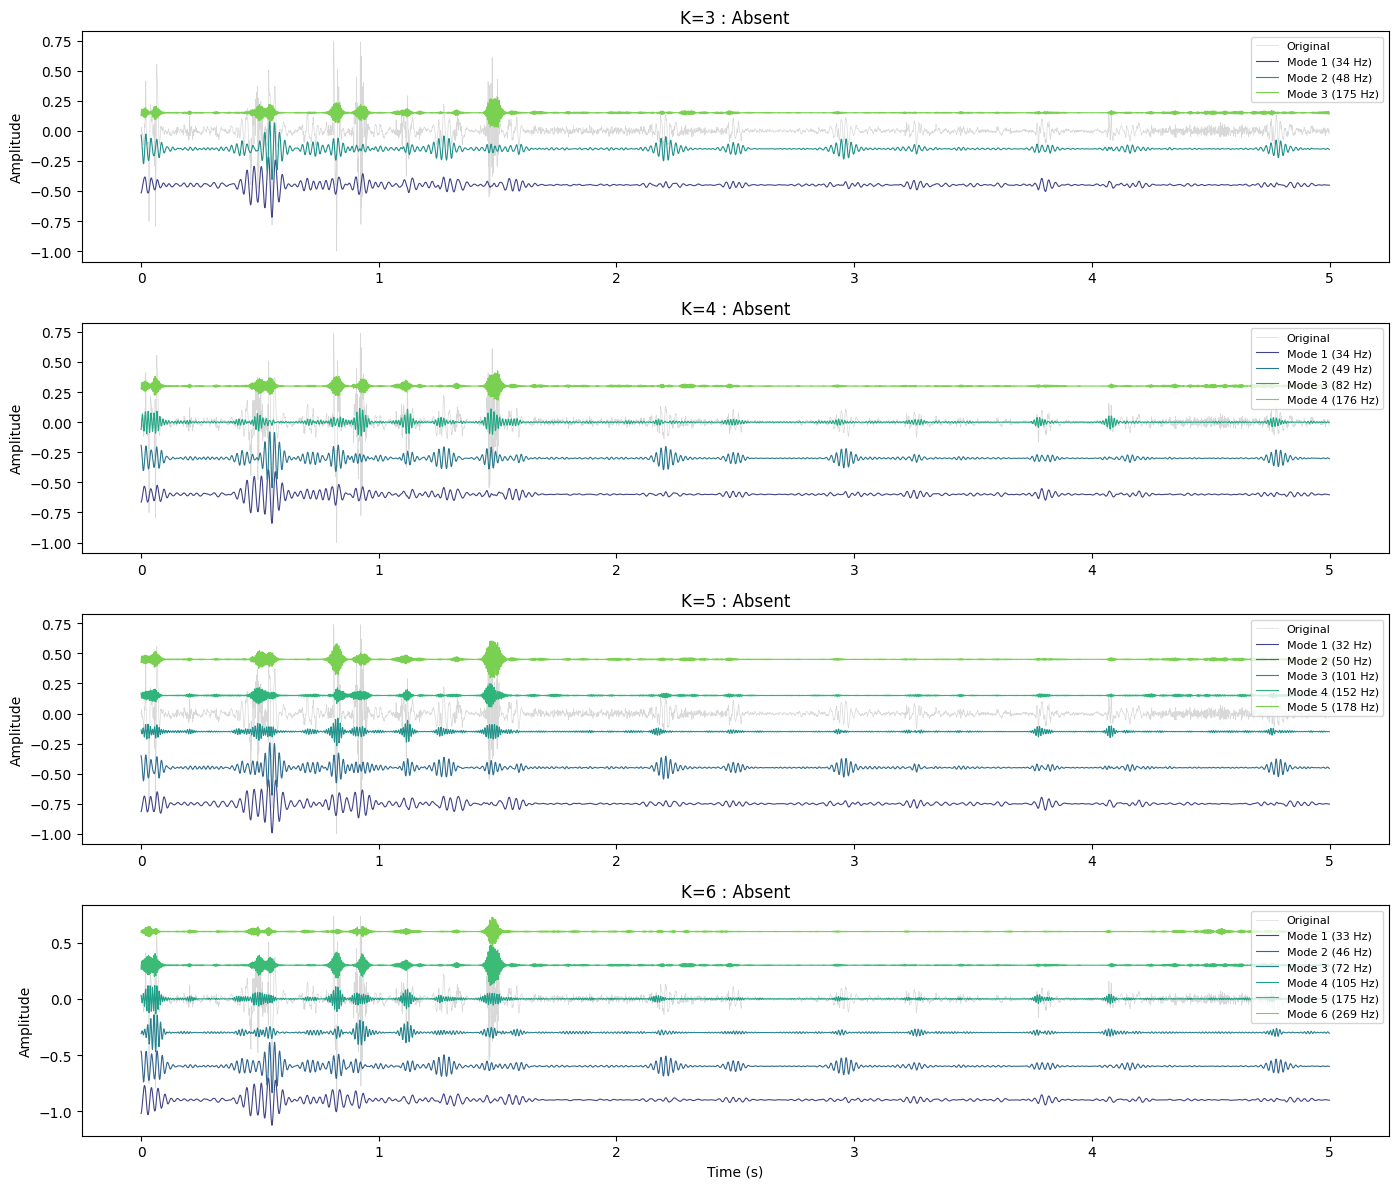

In [5]:
# plotting K comparison for absent sample

fig, axes = plt.subplots(len(K_values), 1, figsize=(14, 3*len(K_values)))

for i, K in enumerate(K_values):
    ax = axes[i]
    res = results_absent[K]
    ax.plot(t, sig_absent, 'gray', alpha=0.3, linewidth=0.5, label='Original')
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, K))
    for k in range(K):
        freq = res['omega'][k] * SAMPLE_RATE
        ax.plot(t, res['u'][k] + 0.3*(k - K/2), color=colors[k], linewidth=0.8,
                label=f'Mode {k+1} ({freq:.0f} Hz)')
    ax.set_title(f'K={K} : Absent')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_K_comparison_absent.png', dpi=150, bbox_inches='tight')
plt.show()

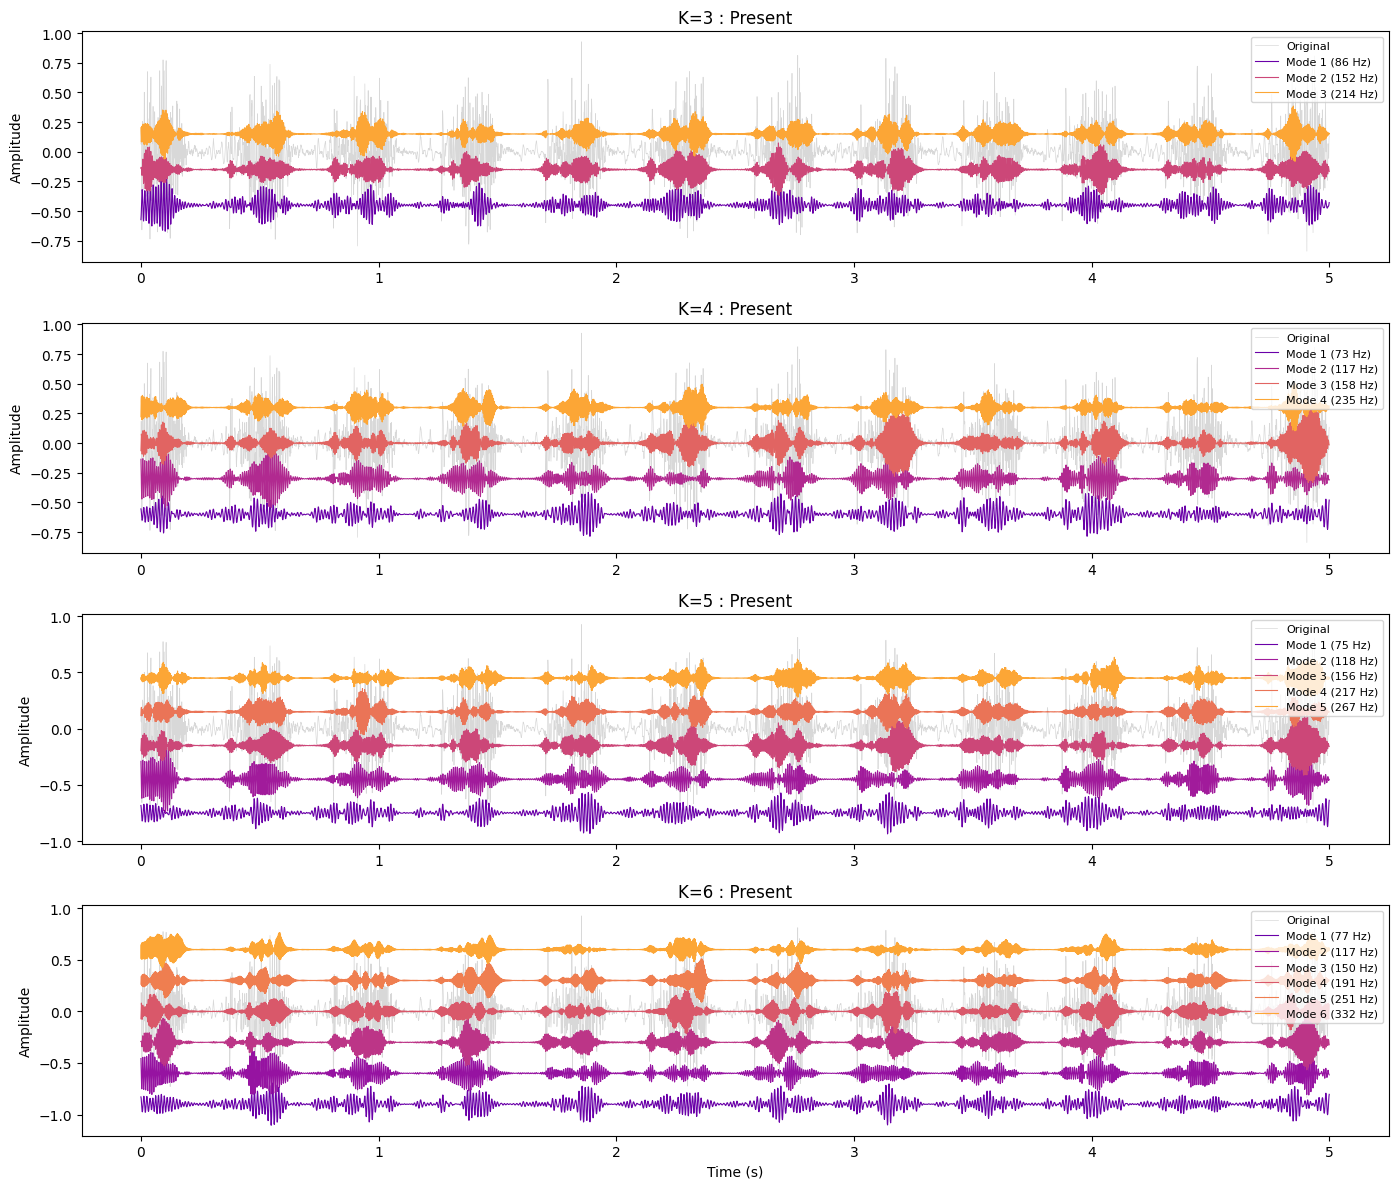

In [6]:
# plotting K comparison for present sample

fig, axes = plt.subplots(len(K_values), 1, figsize=(14, 3*len(K_values)))

for i, K in enumerate(K_values):
    ax = axes[i]
    res = results_present[K]
    ax.plot(t, sig_present, 'gray', alpha=0.3, linewidth=0.5, label='Original')
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, K))
    for k in range(K):
        freq = res['omega'][k] * SAMPLE_RATE
        ax.plot(t, res['u'][k] + 0.3*(k - K/2), color=colors[k], linewidth=0.8,
                label=f'Mode {k+1} ({freq:.0f} Hz)')
    ax.set_title(f'K={K} : Present')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_K_comparison_present.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# analyzing reconstruction quality for each K

print("Reconstruction quality:\n")

for label, signal, results in [('Absent', sig_absent, results_absent),
                                ('Present', sig_present, results_present)]:
    print(f"{label}:")
    for K in K_values:
        res = results[K]
        reconstruction = np.sum(res['u'], axis=0) + res['v']
        mse = np.mean((signal - reconstruction)**2)
        rmse = np.sqrt(mse)
        snr = 10 * np.log10(np.mean(signal**2) / (mse + 1e-10))

        mode_energies = [np.sum(res['u'][k]**2) for k in range(K)]
        jump_energy = np.sum(res['v']**2)
        total_energy = sum(mode_energies) + jump_energy

        print(f"  K={K}: RMSE={rmse:.6f}, SNR={snr:.1f} dB, time={res['time']:.1f}s")
        print(f"        freqs: {[f'{w*SAMPLE_RATE:.0f}' for w in res['omega']]} Hz")
        print(f"        energy: modes {100*sum(mode_energies)/total_energy:.1f}%, jump {100*jump_energy/total_energy:.1f}%")
    print()

Reconstruction quality:

Absent:
  K=3: RMSE=0.031467, SNR=7.7 dB, time=40.1s
        freqs: ['34', '48', '175'] Hz
        energy: modes 43.3%, jump 56.7%
  K=4: RMSE=0.030604, SNR=8.0 dB, time=42.6s
        freqs: ['34', '49', '82', '176'] Hz
        energy: modes 47.8%, jump 52.2%
  K=5: RMSE=0.030330, SNR=8.1 dB, time=42.5s
        freqs: ['32', '50', '101', '152', '178'] Hz
        energy: modes 51.5%, jump 48.5%
  K=6: RMSE=0.028881, SNR=8.5 dB, time=55.2s
        freqs: ['33', '46', '72', '105', '175', '269'] Hz
        energy: modes 66.4%, jump 33.6%

Present:
  K=3: RMSE=0.092360, SNR=5.9 dB, time=35.9s
        freqs: ['86', '152', '214'] Hz
        energy: modes 30.4%, jump 69.6%
  K=4: RMSE=0.092181, SNR=6.0 dB, time=34.9s
        freqs: ['73', '117', '158', '235'] Hz
        energy: modes 45.1%, jump 54.9%
  K=5: RMSE=0.085953, SNR=6.6 dB, time=48.4s
        freqs: ['75', '118', '156', '217', '267'] Hz
        energy: modes 48.6%, jump 51.4%
  K=6: RMSE=0.083065, SNR=6.9 dB

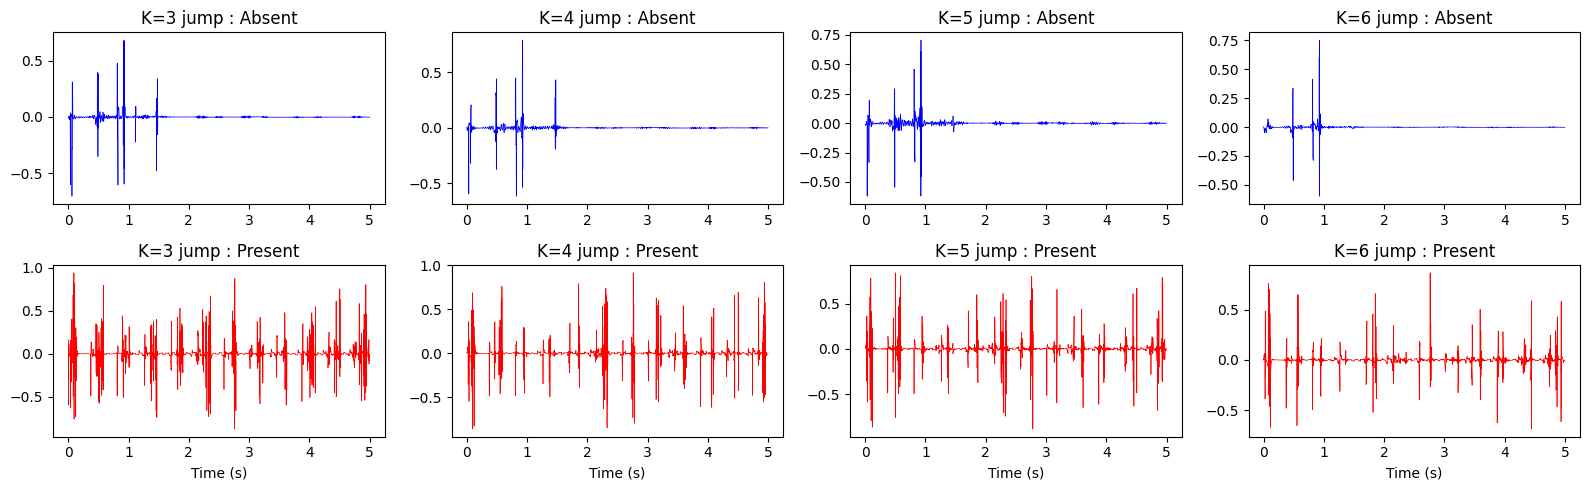

In [8]:
# comparing jump components across K values

fig, axes = plt.subplots(2, len(K_values), figsize=(16, 5))

for i, K in enumerate(K_values):
    axes[0, i].plot(t, results_absent[K]['v'], 'b', linewidth=0.5)
    axes[0, i].set_title(f'K={K} jump : Absent')

    axes[1, i].plot(t, results_present[K]['v'], 'r', linewidth=0.5)
    axes[1, i].set_title(f'K={K} jump : Present')
    axes[1, i].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_K_jump_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# best K after reviewing sweep results above

K_best = 4

## Testing alpha values (bandwidth constraint)
Higher alpha = narrower bandwidth per mode (more frequency-selective). Testing with best K from above.

In [10]:
# running alpha sweep with best K from above

alpha_values = [1000, 3000, 5000, 10000]

alpha_results_absent = {}
alpha_results_present = {}

print(f"Alpha sweep on absent sample (K={K_best}):")
for alpha in alpha_values:
    print(f"  alpha={alpha}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_absent, alpha=alpha, tau=5, beta=0.03, b_bar=0.45, K=K_best, tol=1e-6)
    elapsed = time() - t0
    alpha_results_absent[alpha] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s")

print(f"\nAlpha sweep on present sample (K={K_best}):")
for alpha in alpha_values:
    print(f"  alpha={alpha}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_present, alpha=alpha, tau=5, beta=0.03, b_bar=0.45, K=K_best, tol=1e-6)
    elapsed = time() - t0
    alpha_results_present[alpha] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s")

Alpha sweep on absent sample (K=4):
  alpha=1000... 41.8s
  alpha=3000... 42.3s
  alpha=5000... 31.3s
  alpha=10000... 29.2s

Alpha sweep on present sample (K=4):
  alpha=1000... 28.3s
  alpha=3000... 28.7s
  alpha=5000... 30.1s
  alpha=10000... 30.0s


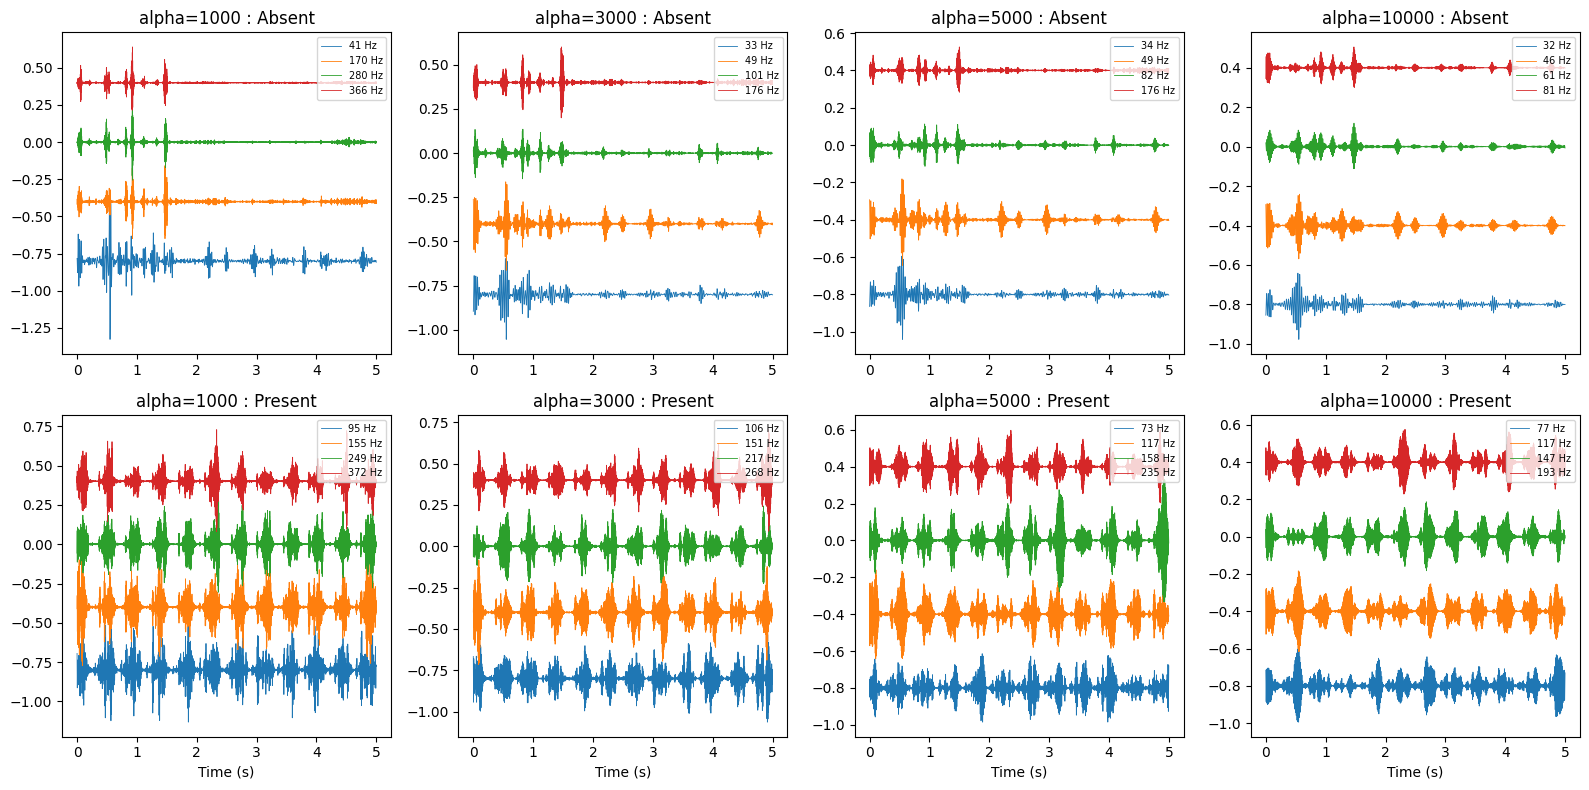

In [11]:
# plotting alpha comparison

fig, axes = plt.subplots(2, len(alpha_values), figsize=(16, 8))

for i, alpha in enumerate(alpha_values):
    ax = axes[0, i]
    res = alpha_results_absent[alpha]
    for k in range(K_best):
        freq = res['omega'][k] * SAMPLE_RATE
        ax.plot(t, res['u'][k] + 0.4*(k - K_best/2), linewidth=0.6, label=f'{freq:.0f} Hz')
    ax.set_title(f'alpha={alpha} : Absent')
    ax.legend(fontsize=7, loc='upper right')

    ax = axes[1, i]
    res = alpha_results_present[alpha]
    for k in range(K_best):
        freq = res['omega'][k] * SAMPLE_RATE
        ax.plot(t, res['u'][k] + 0.4*(k - K_best/2), linewidth=0.6, label=f'{freq:.0f} Hz')
    ax.set_title(f'alpha={alpha} : Present')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# comparing mode frequencies across alpha values

print("Mode frequencies by alpha:\n")

for label, results in [('Absent', alpha_results_absent), ('Present', alpha_results_present)]:
    print(f"{label}:")
    for alpha in alpha_values:
        freqs = results[alpha]['omega'] * SAMPLE_RATE
        print(f"  alpha={alpha:5d}: {[f'{f:.1f}' for f in freqs]} Hz")
    print()

Mode frequencies by alpha:

Absent:
  alpha= 1000: ['41.3', '169.6', '279.6', '365.6'] Hz
  alpha= 3000: ['32.9', '48.5', '101.1', '176.3'] Hz
  alpha= 5000: ['33.9', '48.8', '81.9', '175.7'] Hz
  alpha=10000: ['31.9', '45.6', '60.5', '81.0'] Hz

Present:
  alpha= 1000: ['95.5', '154.9', '248.6', '371.5'] Hz
  alpha= 3000: ['106.5', '150.7', '217.4', '268.4'] Hz
  alpha= 5000: ['72.8', '117.5', '158.1', '235.0'] Hz
  alpha=10000: ['77.0', '117.4', '146.5', '193.1'] Hz



In [13]:
# set best alpha after reviewing sweep results above

alpha_best = 5000

## Testing beta values (jump sparsity)
Beta controls how many jumps are detected. Lower beta = more jumps. Testing with best K and alpha from above.

In [14]:
# running beta sweep with best K and best alpha from above

beta_values = [0.01, 0.03, 0.05, 0.1]

beta_results_absent = {}
beta_results_present = {}

print(f"Beta sweep on absent sample (K={K_best}, alpha={alpha_best}):")
for beta_val in beta_values:
    print(f"  beta={beta_val}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_absent, alpha=alpha_best, tau=5, beta=beta_val, b_bar=0.45, K=K_best, tol=1e-6)
    elapsed = time() - t0
    beta_results_absent[beta_val] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s")

print(f"\nBeta sweep on present sample (K={K_best}, alpha={alpha_best}):")
for beta_val in beta_values:
    print(f"  beta={beta_val}... ", end="", flush=True)
    t0 = time()
    u, v, omega = JMD(sig_present, alpha=alpha_best, tau=5, beta=beta_val, b_bar=0.45, K=K_best, tol=1e-6)
    elapsed = time() - t0
    beta_results_present[beta_val] = {'u': u, 'v': v, 'omega': omega, 'time': elapsed}
    print(f"{elapsed:.1f}s")

Beta sweep on absent sample (K=4, alpha=5000):
  beta=0.01... 30.3s
  beta=0.03... 29.6s
  beta=0.05... 30.7s
  beta=0.1... 3.1s

Beta sweep on present sample (K=4, alpha=5000):
  beta=0.01... 32.0s
  beta=0.03... 31.1s
  beta=0.05... 30.7s
  beta=0.1... 30.5s


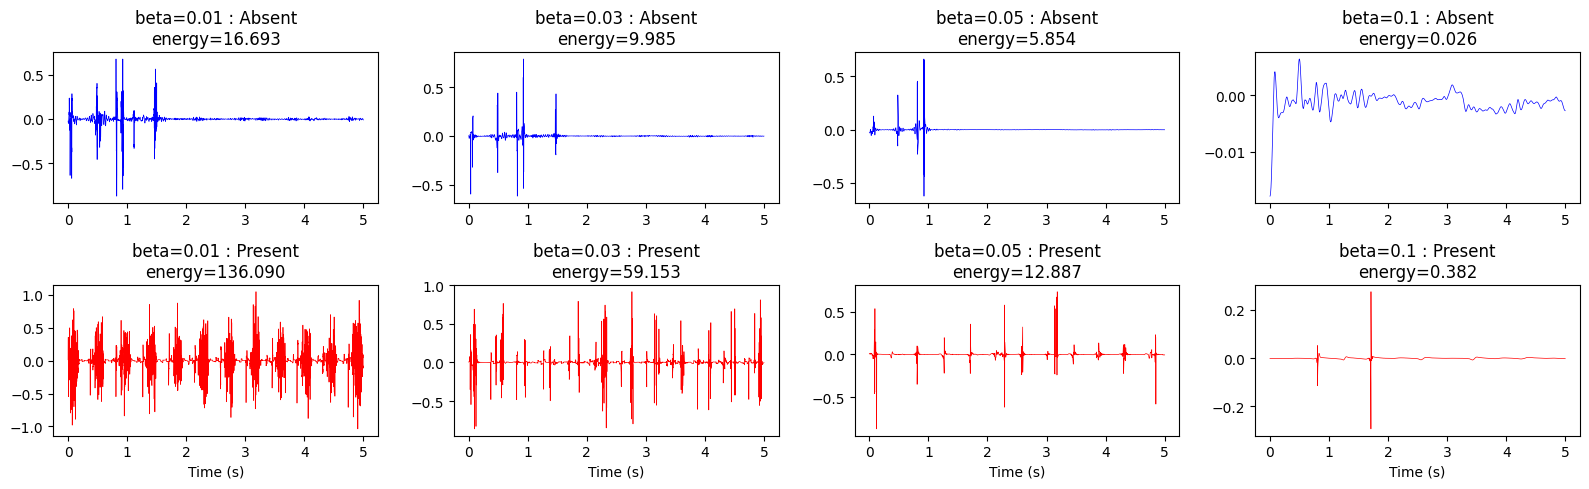

In [15]:
# comparing jump components across beta values

fig, axes = plt.subplots(2, len(beta_values), figsize=(16, 5))

for i, beta_val in enumerate(beta_values):
    v_abs = beta_results_absent[beta_val]['v']
    axes[0, i].plot(t, v_abs, 'b', linewidth=0.5)
    axes[0, i].set_title(f'beta={beta_val} : Absent\nenergy={np.sum(v_abs**2):.3f}')

    v_pres = beta_results_present[beta_val]['v']
    axes[1, i].plot(t, v_pres, 'r', linewidth=0.5)
    axes[1, i].set_title(f'beta={beta_val} : Present\nenergy={np.sum(v_pres**2):.3f}')
    axes[1, i].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_beta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# analyzing beta effect on jump detection

print("Beta effect on jumps:\n")

for label, signal, results in [('Absent', sig_absent, beta_results_absent),
                                ('Present', sig_present, beta_results_present)]:
    print(f"{label}:")
    for beta_val in beta_values:
        res = results[beta_val]
        v = res['v']
        dv = np.diff(v)
        threshold = 0.01 * np.max(np.abs(signal))
        n_jumps = np.sum(np.abs(dv) > threshold)
        jump_energy = np.sum(v**2)
        tv = np.sum(np.abs(dv))

        reconstruction = np.sum(res['u'], axis=0) + v
        rmse = np.sqrt(np.mean((signal - reconstruction)**2))

        print(f"  beta={beta_val:.2f}: jumps~{n_jumps:4d}, energy={jump_energy:.3f}, TV={tv:.3f}, RMSE={rmse:.6f}")
    print()

Beta effect on jumps:

Absent:
  beta=0.01: jumps~ 328, energy=16.693, TV=44.634, RMSE=0.020996
  beta=0.03: jumps~  41, energy=9.985, TV=19.801, RMSE=0.030604
  beta=0.05: jumps~  80, energy=5.854, TV=10.274, RMSE=0.035272
  beta=0.10: jumps~   0, energy=0.026, TV=0.158, RMSE=0.041062

Present:
  beta=0.01: jumps~1860, energy=136.090, TV=371.870, RMSE=0.049750
  beta=0.03: jumps~ 500, energy=59.153, TV=120.054, RMSE=0.092181
  beta=0.05: jumps~ 276, energy=12.887, TV=27.943, RMSE=0.110269
  beta=0.10: jumps~  23, energy=0.382, TV=1.807, RMSE=0.115738



In [17]:
# set best beta after reviewing sweep results above

beta_best = 0.03

## Selecting final parameters
Choosing based on the sweep results above.

In [18]:
# assembling final parameters from selections above

final_params = {
    'K': K_best,
    'alpha': alpha_best,
    'tau': 5,
    'beta': beta_best,
    'b_bar': 0.45,
    'tol': 1e-6
}

print("Selected parameters:")
for k, val in final_params.items():
    print(f"  {k}: {val}")

print("\nReasoning:")
print("  K=4: covers key PCG bands cleanly, K=5/6 add modes that cluster or split at 1000 Hz")
print("  alpha=5000: captures low-freq S1 content from 73 Hz, alpha=3000 misses that band")
print("  beta=0.03: sparse jump component, 41 jumps in 5s is physiologically coherent")
print("  tau=5, b_bar=0.45: ADMM reference defaults, stable convergence")


Selected parameters:
  K: 4
  alpha: 5000
  tau: 5
  beta: 0.03
  b_bar: 0.45
  tol: 1e-06

Reasoning:
  K=4: covers key PCG bands cleanly, K=5/6 add modes that cluster or split at 1000 Hz
  alpha=5000: captures low-freq S1 content from 73 Hz, alpha=3000 misses that band
  beta=0.03: sparse jump component, 41 jumps in 5s is physiologically coherent
  tau=5, b_bar=0.45: ADMM reference defaults, stable convergence


Decomposing with final parameters...

Absent:  29.4s, freqs: ['34', '49', '82', '176'] Hz
Present: 30.6s, freqs: ['73', '117', '158', '235'] Hz


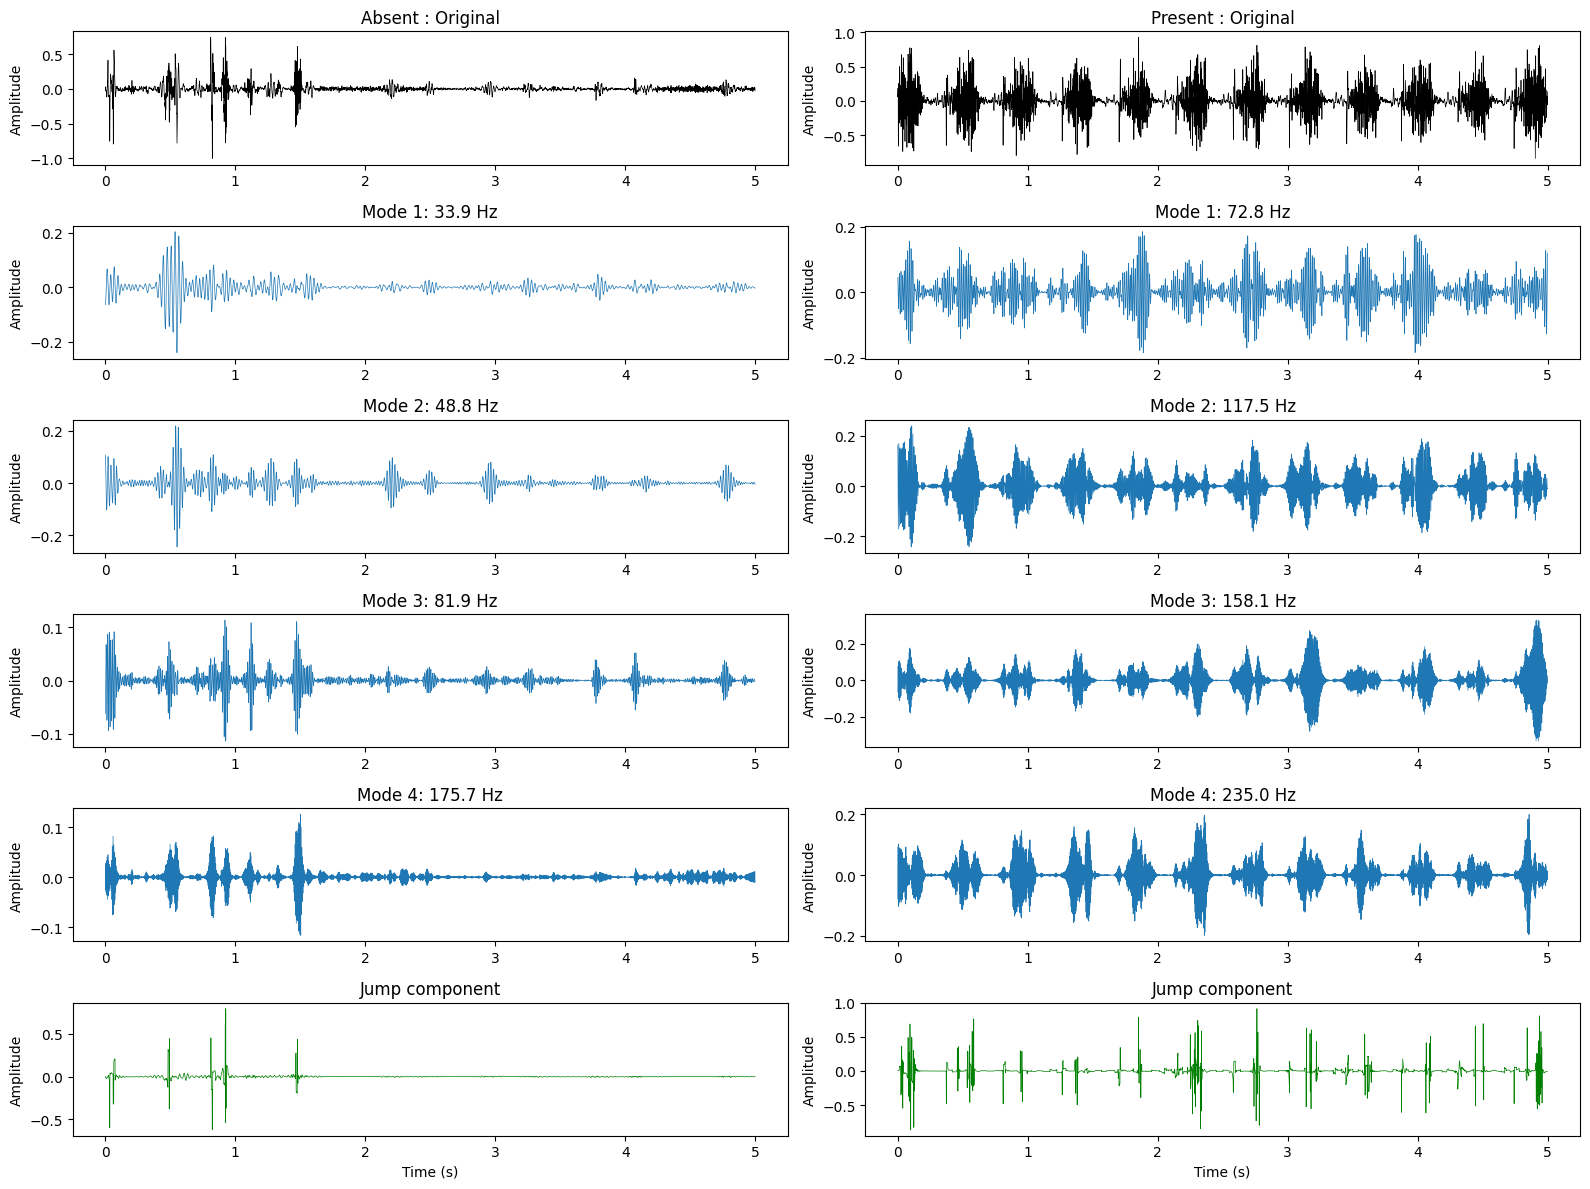

In [19]:
# running final decomposition with selected parameters

print("Decomposing with final parameters...\n")

t0 = time()
u_absent, v_absent, omega_absent = JMD(sig_absent, **final_params)
print(f"Absent:  {time() - t0:.1f}s, freqs: {[f'{w*SAMPLE_RATE:.0f}' for w in omega_absent]} Hz")

t0 = time()
u_present, v_present, omega_present = JMD(sig_present, **final_params)
print(f"Present: {time() - t0:.1f}s, freqs: {[f'{w*SAMPLE_RATE:.0f}' for w in omega_present]} Hz")

K = final_params['K']

fig = plt.figure(figsize=(16, 12))

for col, (signal, u, v, omega, label) in enumerate([
    (sig_absent, u_absent, v_absent, omega_absent, 'Absent'),
    (sig_present, u_present, v_present, omega_present, 'Present')
]):
    ax = plt.subplot(K + 2, 2, col + 1)
    ax.plot(t, signal, 'k', linewidth=0.5)
    ax.set_title(f'{label} : Original')
    ax.set_ylabel('Amplitude')

    for k in range(K):
        ax = plt.subplot(K + 2, 2, 2*(k+1) + col + 1)
        ax.plot(t, u[k], linewidth=0.5)
        ax.set_title(f'Mode {k+1}: {omega[k]*SAMPLE_RATE:.1f} Hz')
        ax.set_ylabel('Amplitude')

    ax = plt.subplot(K + 2, 2, 2*(K+1) + col + 1)
    ax.plot(t, v, 'g', linewidth=0.5)
    ax.set_title('Jump component')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'block4_final_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# saving final parameters

params_path = PROCESSED_DIR / 'jmd_params.json'

with open(params_path, 'w') as f:
    json.dump(final_params, f, indent=2)

print(f"Saved to {params_path}")
print(json.dumps(final_params, indent=2))

Saved to D:\sop\data\processed\jmd_params.json
{
  "K": 4,
  "alpha": 5000,
  "tau": 5,
  "beta": 0.03,
  "b_bar": 0.45,
  "tol": 1e-06
}


In [21]:
# testing robustness on additional samples

n_test = 5
test_absent = absent_orig.sample(n_test, random_state=123)
test_present = present_orig.sample(n_test, random_state=123)

print("Robustness test with final parameters:\n")

print("Absent samples:")
for _, row in test_absent.iterrows():
    sig = np.load(row['npy_path']).astype(np.float64)[:CLIP_SAMPLES]
    t0 = time()
    u, v, omega = JMD(sig, **final_params)
    elapsed = time() - t0
    recon = np.sum(u, axis=0) + v
    rmse = np.sqrt(np.mean((sig - recon)**2))
    freqs = omega * SAMPLE_RATE
    print(f"  {row['file']}: RMSE={rmse:.6f}, {elapsed:.1f}s, {[f'{f:.0f}' for f in freqs]} Hz")

print("\nPresent samples:")
for _, row in test_present.iterrows():
    sig = np.load(row['npy_path']).astype(np.float64)[:CLIP_SAMPLES]
    t0 = time()
    u, v, omega = JMD(sig, **final_params)
    elapsed = time() - t0
    recon = np.sum(u, axis=0) + v
    rmse = np.sqrt(np.mean((sig - recon)**2))
    freqs = omega * SAMPLE_RATE
    print(f"  {row['file']}: RMSE={rmse:.6f}, {elapsed:.1f}s, {[f'{f:.0f}' for f in freqs]} Hz")

Robustness test with final parameters:

Absent samples:
  a428_AV.wav: RMSE=0.020262, 36.2s, ['13', '46', '171', '221'] Hz
  a380_AV.wav: RMSE=0.006786, 30.2s, ['35', '65', '88', '162'] Hz
  a598_TV.wav: RMSE=0.014563, 26.4s, ['34', '64', '84', '111'] Hz
  a401_MV.wav: RMSE=0.016888, 27.0s, ['38', '107', '187', '273'] Hz
  a318_TV.wav: RMSE=0.012220, 27.2s, ['37', '59', '81', '109'] Hz

Present samples:
  p121_MV.wav: RMSE=0.021124, 28.1s, ['26', '65', '122', '205'] Hz
  p102_TV.wav: RMSE=0.056222, 26.0s, ['49', '84', '124', '162'] Hz
  p6_MV.wav: RMSE=0.014448, 28.2s, ['36', '47', '73', '141'] Hz
  p77_MV.wav: RMSE=0.023725, 27.7s, ['112', '150', '256', '297'] Hz
  p165_PV.wav: RMSE=0.010095, 28.7s, ['38', '52', '64', '119'] Hz
